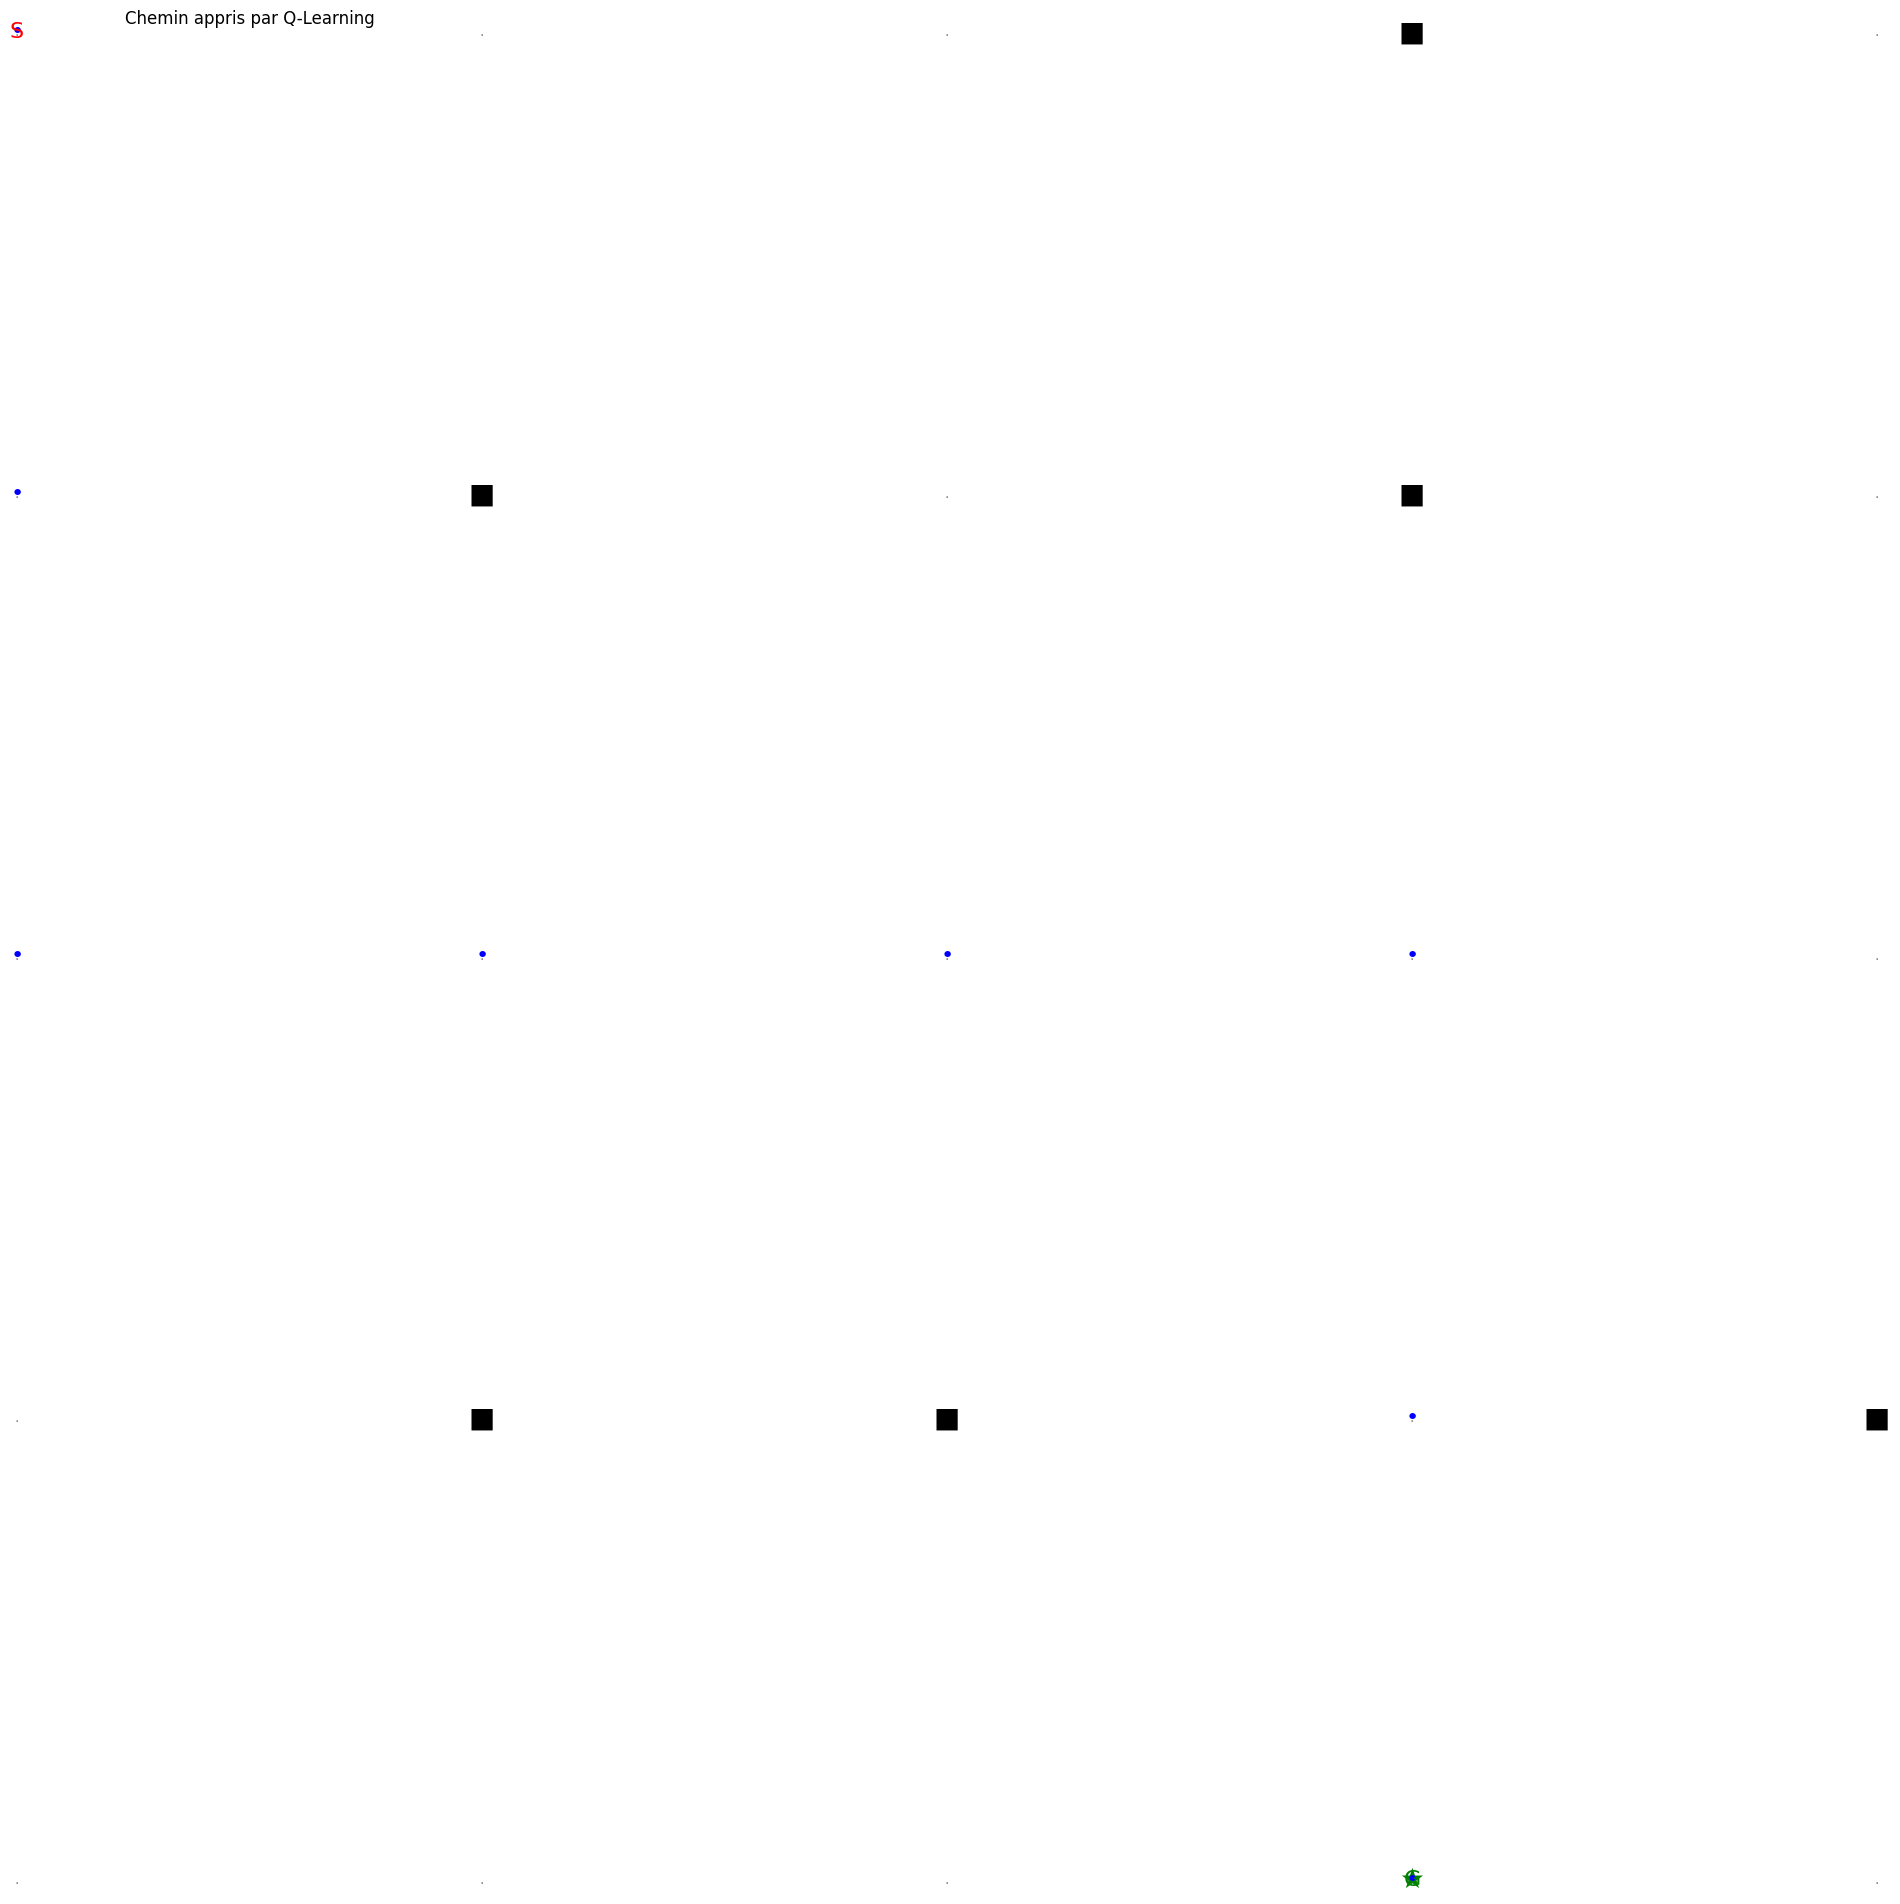

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
import time

# =======================
# 1. Création du labyrinthe
# =======================
labyrinthe = np.array([
    [ 0,  0,  0, -1,  0],
    [ 0, -1,  0, -1,  0],
    [ 0,  0,  0,  0,  0],
    [ 0, -1, -1,  0, -1],
    [ 0,  0,  0,  1,  0]
])

rows, cols = labyrinthe.shape
start_position = (0, 0)  # départ
goal_position = (4, 3)   # position de la récompense

# Actions : 0=haut, 1=bas, 2=gauche, 3=droite
actions = [0, 1, 2, 3]
num_actions = len(actions)

# =======================
# 2. Fonction de déplacement
# =======================
def move(x, y, action):
    if action == 0:       # haut
        nx, ny = x - 1, y
    elif action == 1:     # bas
        nx, ny = x + 1, y
    elif action == 2:     # gauche
        nx, ny = x, y - 1
    elif action == 3:     # droite
        nx, ny = x, y + 1

    # Vérifier les limites
    if nx < 0 or nx >= rows or ny < 0 or ny >= cols:
        return x, y, -5, False

    cell = labyrinthe[nx, ny]

    if cell == -1:
        return x, y, -5, False  # mur
    elif cell == 1:
        return nx, ny, 10, True  # objectif
    else:
        return nx, ny, -1, False  # case libre

# =======================
# 3. Initialisation de la table Q
# =======================
Q = np.zeros((rows, cols, num_actions))

# Hyperparamètres
alpha = 0.1     # taux d’apprentissage
gamma = 0.9     # facteur de discount
epsilon = 0.2   # taux d’exploration
episodes =1000  # nombre d’épisodes

# =======================
# 4. Algorithme Q-Learning
# =======================
for ep in range(episodes):
    x, y = start_position
    done = False

    while not done:
        # Choisir une action (exploration ou exploitation)
        if random.uniform(0, 1) < epsilon:
            action = random.choice(actions)
        else:
            action = np.argmax(Q[x, y])

        # Effectuer l’action
        nx, ny, reward, done = move(x, y, action)

        # Mettre à jour Q
        Q[x, y, action] = Q[x, y, action] + alpha * (
            reward + gamma * np.max(Q[nx, ny]) - Q[x, y, action]
        )

        # Aller à la nouvelle position
        x, y = nx, ny

# =======================
# 5. Affichage du chemin appris
# =======================
def get_best_path():
    path = [start_position]
    x, y = start_position
    for _ in range(30):  # limite pour éviter boucle infinie
        action = np.argmax(Q[x, y])
        nx, ny, _, done = move(x, y, action)
        path.append((nx, ny))
        if done:
            break
        x, y = nx, ny
    return path

path = get_best_path()

# =======================
# 6. Visualisation du labyrinthe et du chemin
# =======================
plt.figure(figsize=(6,6))
for i in range(rows):
    for j in range(cols):
        if labyrinthe[i, j] == -1:
            plt.text(j, i, "■", ha='center', va='center', color='black', fontsize=20)
        elif labyrinthe[i, j] == 1:
            plt.text(j, i, "★", ha='center', va='center', color='green', fontsize=20)
        else:
            plt.text(j, i, ".", ha='center', va='center', color='gray')

# Dessiner le chemin
for (i, j) in path:
    plt.text(j, i, "•", ha='center', va='center', color='blue', fontsize=16)

# Départ et arrivée
plt.text(start_position[1], start_position[0], "S", ha='center', va='center', color='red', fontsize=16)
plt.text(goal_position[1], goal_position[0], "G", ha='center', va='center', color='green', fontsize=16)

plt.gca().invert_yaxis()
plt.title("Chemin appris par Q-Learning")
plt.axis('off')
plt.show()
